In [23]:
# We start by importing all the necessary packages
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


In [24]:
def f_rk4(x, delx,N=40, F = 8):
    dX = torch.zeros((N,1))
    for i in range(N):
        dX[i,0] = (x[(i+1)%N,0] - x[(i-2)%N,0]) * x[(i-1)%N,0] - x[i,0] + F
    return dX
        

In [25]:
# We will now define our Lorenz function
def L96(x, delx, delt,N = 40, F=8):
    k1 = x
    k2 = x + (delt/2) * f_rk4(k1, delx)
    k3 = x + (delt/2) * f_rk4(k2, delx)
    k4 = x + delt * f_rk4(k3, delx)
    next_step = x + (delt/6) * (f_rk4(k1, delx)+ 2 * f_rk4(k2, delx) + 2 * f_rk4(k3, delx) + f_rk4(k4, delx))
    return next_step


In [26]:
N = 40
x_in = torch.rand((N,1))
results = x_in
delx = 1
delt = 0.005 # 6 hours according to Lorenz
time_steps = 14400 # this is ten years according to Lorenz 
for i in tqdm(range(time_steps)):
    x_out = L96(x_in, delx, delt)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out
    
    


100%|██████████| 14400/14400 [00:37<00:00, 386.72it/s]


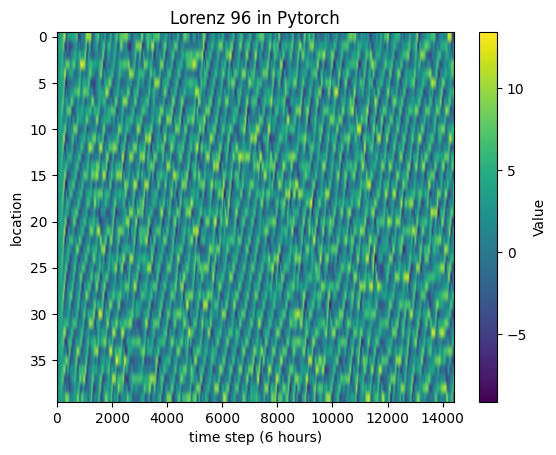

In [7]:
plt.imshow(results.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Lorenz 96 in Pytorch")
plt.show()

In [9]:
# We will now find the Jacobian of the Lorenz 96 model
delx = torch.tensor(delx, dtype=torch.float32, requires_grad=True)
delt = torch.tensor(delt, dtype=torch.float32, requires_grad=True)
der_L96 = torch.autograd.functional.jacobian(L96,(x_in,delx,delt))



/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_45433/65910387.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  delx = torch.tensor(delx, dtype=torch.float32, requires_grad=True)
/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_45433/65910387.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  delt = torch.tensor(delt, dtype=torch.float32, requires_grad=True)


In [10]:
print(len(der_L96))
dL96dx = der_L96[0].squeeze()
print(dL96dx.size())
print(dL96dx[6])

3
torch.Size([40, 40])
tensor([ 2.8533e-08, -9.9713e-07, -2.2073e-05,  8.5399e-05,  1.2295e-03,
        -9.3884e-03,  9.9492e-01, -1.2283e-03, -2.2468e-05, -8.6699e-08,
         2.2371e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  2.3444e-10, -3.9878e-09])


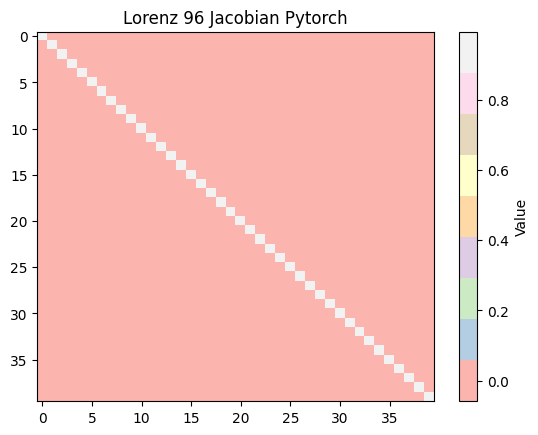

In [11]:
plt.imshow(dL96dx.cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("Lorenz 96 Jacobian Pytorch")
plt.show()

We will now run the TLM test
We want to see how well the TLM can emulate the small perturbation
$|L96(x + x',A) - L96(x,A) - \frac{\partial L96}{\partial x} x'|$

In [13]:
# We start by running the model for 400 time steps
x_in = torch.rand((N,1))
results = x_in
delx = 1
delt = 0.005 # 6 hours according to Lorenz
time_steps = 14400 # this is ten years according to Lorenz 


for i in tqdm(range(400)):
    x_out = L96(x_in, delx, delt)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out
    plot = x_in.cpu().numpy().flatten()

    # plt.plot(plot)
    # plt.title(f"Step {i}")
    # plt.xlabel("Index")
    # plt.ylabel("Value")
    # plt.savefig(f'/Users/isaacmiles-fine/Documents/PhD/2026/Lorenz_pytorch/first_run/plot_{i+1}.png')
    # plt.close()



100%|██████████| 400/400 [00:00<00:00, 408.61it/s]


In [14]:
# We will now add a small perturbation
x_pert = torch.rand(N,1)*10**(-5)
x_in_pert = x_out + x_pert
x_out_pert = L96(x_in_pert, delx, delt)
x_out_unpert = L96(x_out, delx, delt)
TLM_test = x_out_pert - x_out_unpert - torch.matmul(dL96dx, x_pert)

In [15]:
error = torch.sum((torch.abs(TLM_test)))
print(error)

tensor(1.0849e-05)


In [16]:
# Now that we have the Jacobian from autograd we will attempt to find the TLM using ensemble methods
ensemble_size = 1000
x_in = torch.rand((N,1))
results = x_in
delx = 1
delt = 0.005 # 6 hours according to Lorenz
time_steps = 14400 # this is ten years according to Lorenz 


for i in tqdm(range(400)):
    x_out = L96(x_in, delx, delt)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out

X = torch.zeros(N, ensemble_size)
Chi = torch.zeros(N, ensemble_size)

for i in tqdm(range(ensemble_size)):
    x_pert = torch.rand(N,1)*10**(-5)
    x_in_pert = x_out + x_pert
    x_out_pert = L96(x_in_pert, delx, delt)
    x_out_unpert = L96(x_out, delx, delt)
    Chi_i = x_out_pert - x_out_unpert
    X[:,i] = x_pert.squeeze()
    Chi[:,i] = Chi_i.squeeze()
    
    

100%|██████████| 1000/1000 [00:04<00:00, 210.19it/s]


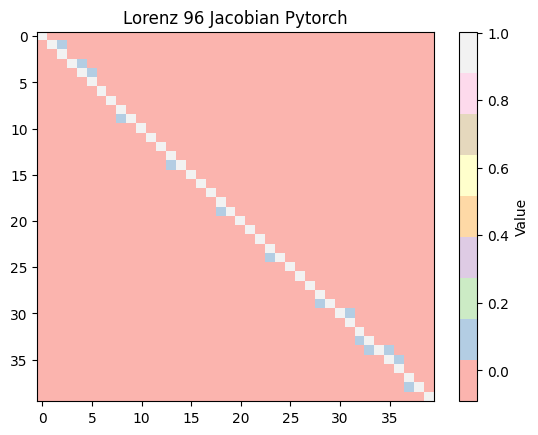

In [17]:
M = Chi @ torch.transpose(X,0,1) @ torch.linalg.inv( torch.matmul(X,  torch.transpose(X,0,1)))
plt.imshow(M.cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("Lorenz 96 Jacobian Pytorch")
plt.show()

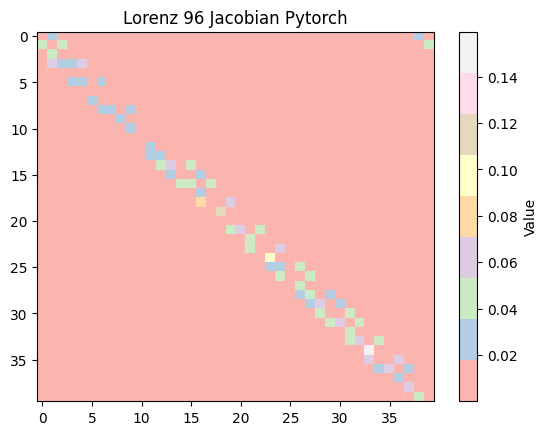

In [18]:
plt.imshow((torch.abs(M- dL96dx)).cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("Lorenz 96 Jacobian Pytorch")
plt.show()

In [19]:
# We will now do the same TLM test as before and compare the results
# We will now add a small perturbation
x_pert = torch.rand(N,1)*10**(-5)
x_in_pert = x_out + x_pert
x_out_pert = L96(x_in_pert, delx, delt)
x_out_unpert = L96(x_out, delx, delt)
TLM_test = x_out_pert - x_out_unpert - torch.matmul(M, x_pert)
error = torch.sum((torch.abs(TLM_test)))
print(error)

tensor(3.1951e-06)
